In [4]:
import scipy.io as sio

data = sio.loadmat("../data/dataset_2classes_20ms_100kHz.mat")
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'N', 'delay_vect', 'down', 'labelappliances', 'labelsTest', 'labelsTrain', 'lengthwin', 'overlap', 'step', 'yTest', 'yTrain'])


In [5]:
print("yTrain:", data["yTrain"].shape)
print("labelsTrain:", data["labelsTrain"].shape)

print("yTest:", data["yTest"].shape)
print("labelsTest:", data["labelsTest"].shape)

yTrain: (1334, 2000)
labelsTrain: (1334, 1)
yTest: (1334, 2000)
labelsTest: (1334, 1)


In [ ]:
# Train data dataframe

import pandas as pd
train_df = pd.DataFrame(data["yTrain"])

train_df["label"] = data["labelsTrain"].ravel()

#train_df.to_csv("../data/train.csv", index=False)

In [ ]:
# Test data dataframe

test_df = pd.DataFrame(data["yTest"])

test_df["label"] = data["labelsTest"].ravel()

#test_df.to_csv("../data/test.csv", index=False)

In [30]:
print(train_df.isnull().sum())

0        0
1        0
2        0
3        0
4        0
        ..
1996     0
1997     0
1998     0
1999     0
label    0
Length: 2001, dtype: int64


In [6]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,1991,1992,1993,1994,1995,1996,1997,1998,1999,label
0,0.462629,0.463991,0.463734,0.466172,0.466952,0.468737,0.476024,0.473891,0.474316,0.476724,...,0.828011,0.826267,0.830892,0.827196,0.828707,0.831292,0.835195,0.835608,0.832283,0
1,0.842470,0.841325,0.840311,0.841637,0.845205,0.846148,0.847083,0.847936,0.848248,0.849373,...,0.802703,0.802638,0.806026,0.806672,0.805542,0.808627,0.809449,0.810328,0.811098,0
2,0.779529,0.781603,0.780489,0.779921,0.783326,0.783342,0.786882,0.786030,0.787001,0.787664,...,0.645451,0.645838,0.646558,0.647636,0.646727,0.648544,0.646624,0.649717,0.650654,0
3,0.561677,0.561495,0.561916,0.565481,0.565165,0.567357,0.568186,0.568395,0.566778,0.566810,...,0.555941,0.556968,0.557973,0.556764,0.557710,0.559287,0.561872,0.562326,0.561140,0
4,0.562806,0.561835,0.564027,0.566008,0.564043,0.566990,0.568713,0.568435,0.568342,0.572817,...,0.551672,0.552084,0.553182,0.551927,0.554516,0.556752,0.558355,0.563798,0.561885,0


In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1334 entries, 0 to 1333
Columns: 2001 entries, 0 to label
dtypes: float32(2000), uint8(1)
memory usage: 10.2 MB


In [8]:
print("Training:", train_df.shape)
print("Testing:", test_df.shape)

Training: (1334, 2001)
Testing: (1334, 2001)


In [9]:
train_df["label"].value_counts()

label
0    863
1    471
Name: count, dtype: int64

In [10]:
test_df["label"].value_counts()

label
0    861
1    473
Name: count, dtype: int64

In [11]:
import matplotlib.pyplot as plt

waveform = train_df.iloc[0, :-1]

print(type(waveform))
waveform.head()


<class 'pandas.Series'>


0    0.462629
1    0.463991
2    0.463734
3    0.466172
4    0.466952
Name: 0, dtype: float32

0.0


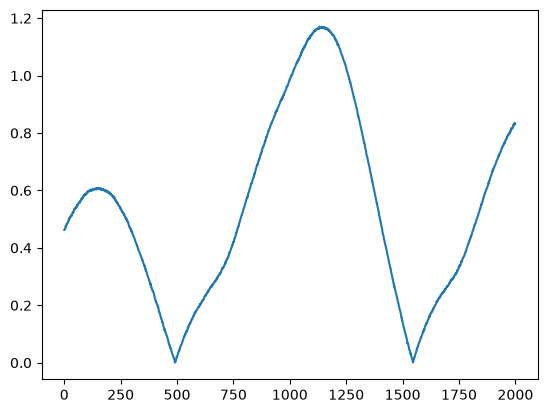

In [12]:
print(train_df.iloc[0]["label"])

plt.plot(waveform)
plt.show()

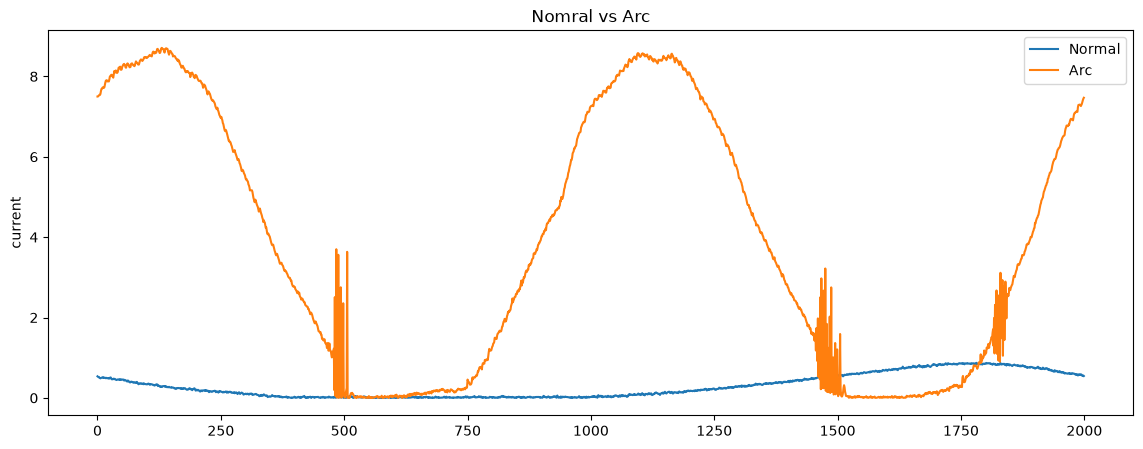

In [ ]:
normal_df = train_df[train_df["label"]==0]
n_wave = normal_df.sample(1).iloc[0, :-1]

arc_df = train_df[train_df["label"]==1]
a_wave = arc_df.sample(1).iloc[0, :-1]

plt.figure(figsize=(14, 5))

plt.plot(n_wave, label="Normal")
plt.plot(a_wave, label="Arc")

plt.ylabel("current")
plt.title("Nomral vs Arc")

plt.legend()
plt.show()

# Since there seems to be load data of multiple appliances in the data set randomly comparing the waves may not be useful as all waves will seem like an arc
# eg:- we could be comparing a normal wave of an vaccum cleaner and a arc wave of a TV (different loads)

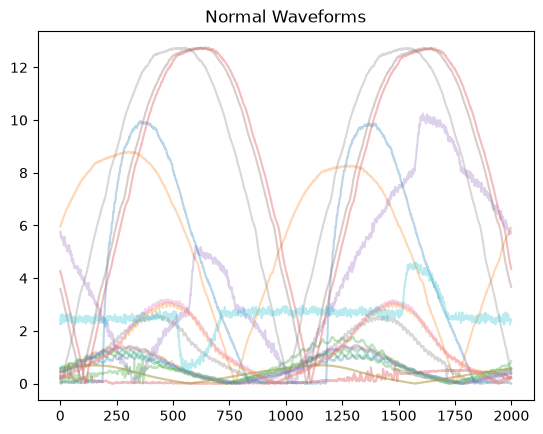

In [32]:
plt.Figure(figsize=(12, 4))

for i in range (20):
    wave = normal_df.sample(1).iloc[0, :-1]
    plt.plot(wave, alpha=0.3)

plt.title("Normal Waveforms")
plt.show()


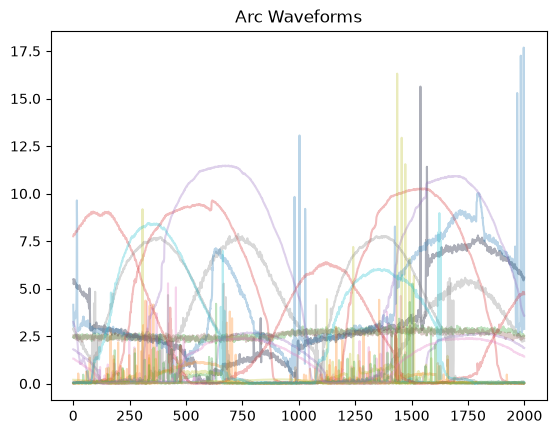

In [35]:
plt.Figure(figsize=(12, 4))

for i in range (20):
    wave = arc_df.sample(1).iloc[0, :-1]
    plt.plot(wave, alpha=0.3)

plt.title("Arc Waveforms")
plt.show()